# CO₂ brotando del fondo del mar: el campo de seeps de Mayotte

Frente a Mayotte, a más de 1.300 metros bajo el agua, hay grietas en el fondo del mar por donde sale dióxido de carbono. No es una metáfora: gotas y burbujas de CO₂ escapando del lecho marino, con montículos de hidrato de gas creciendo alrededor.

**¿Cuánto CO₂ se fuga de ese campo cada año?**

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** *Large CO₂ seeps and hydrate field on the seafloor offshore Mayotte Island* — Cathalot et al. (2026)  
**Journal:** Nature Geoscience · [DOI: 10.1038/s41561-026-02004-2](https://doi.org/10.1038/s41561-026-02004-2)  
**Datos:** SEANOE · [DOI: 10.17882/109663](https://doi.org/10.17882/109663)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-12-co2-seeps-hidratos-mayotte/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/_SS-jYyd2e4)

## El fondo del mar que empezó a soltar CO₂

En 2018, frente a la isla de Mayotte (océano Índico), nació un volcán submarino — el mayor evento volcánico submarino registrado hasta la fecha. Años después, una expedición bajó el ROV (robot submarino) Victor 6000 entre 1.220 y 1.509 metros de profundidad y se encontró con un campo de fuentes (*seeps*) soltando CO₂, salpicado de montículos de hidrato de gas.

El equipo hizo dos cosas que podemos seguir con los datos publicados: midió el caudal de **22 fuentes individuales**, una por una, y a partir de esas mediciones extrapoló cuánto CO₂ suelta el campo entero. Vamos a recorrer ambos pasos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_ALTO = 40.0            # ml/s a partir del cual una fuente es de caudal "alto"
COLOR_ALTO  = '#DC2626'       # caudal alto (rojo)
COLOR_MEDIO = '#2563EB'       # caudal medio (azul CaM)
COLOR_BAJO  = '#D97706'       # caudal bajo (ámbar)
COLOR_NORMAL = '#7C3AED'      # modelo espacial Normal (violeta)
COLOR_OTROS = '#059669'       # modelos Random/Dirichlet (esmeralda)
FUENTE = 'Fuente: Cathalot et al. (2026), Nature Geoscience | Datos: SEANOE 10.17882/109663'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local -> /tmp -> GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de datos
seeps = pd.read_csv('datos/mediciones_seeps.csv')
flux  = pd.read_csv('datos/flux_extrapolado.csv')

print(f'Mediciones directas: {len(seeps)} fuentes en {seeps["site"].nunique()} sitios')
print(f'Profundidad: {seeps["depth_m"].min():.0f} - {seeps["depth_m"].max():.0f} m')
print(f'Caudal (ml/s): mediana {seeps["flow_rate_mls"].median():.2f}, '
      f'min {seeps["flow_rate_mls"].min():.2f}, max {seeps["flow_rate_mls"].max():.2f}')
print()
print(f'Extrapolacion Monte Carlo: {len(flux)} estimaciones')
print(f'Modelos espaciales: {sorted(flux["dist_model"].unique())}')
print(f'Modelos de densidad: {sorted(flux["dens_model"].unique())}')

Mediciones directas: 22 fuentes en 5 sitios
Profundidad: 1220 - 1509 m
Caudal (ml/s): mediana 19.24, min 1.54, max 132.50

Extrapolacion Monte Carlo: 6000 estimaciones
Modelos espaciales: ['Dirichlet', 'Normal', 'Random']
Modelos de densidad: ['Beta', 'Normal']


## Las 22 fuentes

Aquí están.

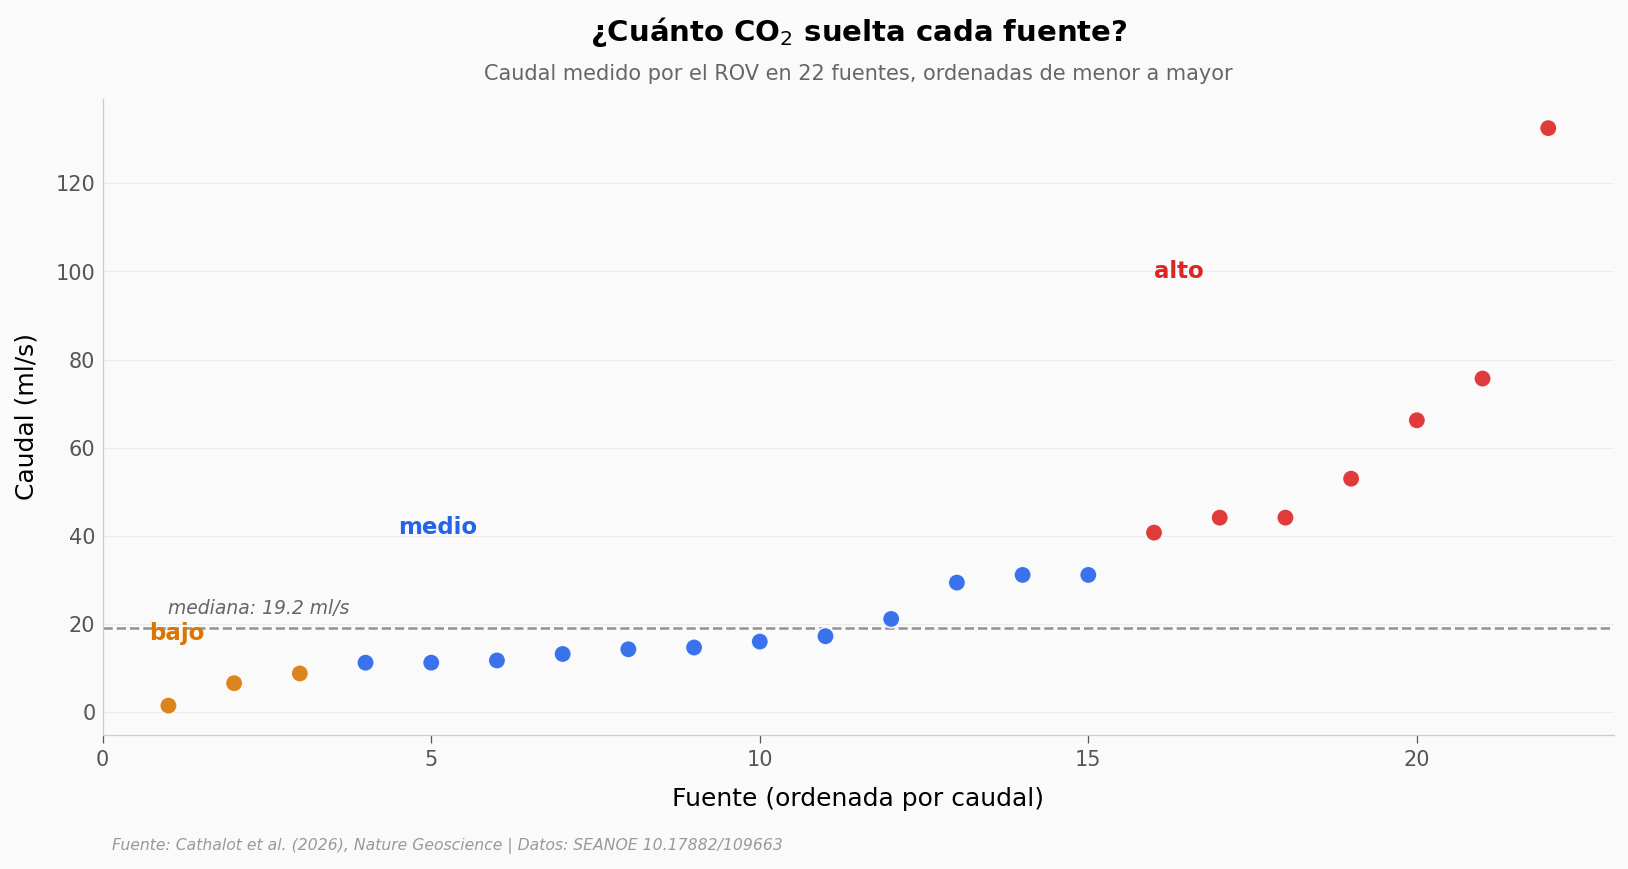

In [2]:
# Gráfica hero: las 22 fuentes ordenadas por caudal, coloreadas por tipo
fig, ax = plt.subplots(figsize=(13, 5.5))

s = seeps.sort_values('flow_rate_mls').reset_index(drop=True)
colores = {'High': COLOR_ALTO, 'Medium': COLOR_MEDIO, 'Low': COLOR_BAJO}
rank = np.arange(1, len(s) + 1)
ax.scatter(rank, s['flow_rate_mls'],
           color=[colores[t] for t in s['typology']],
           s=70, alpha=0.9, edgecolors='white', linewidths=0.8, zorder=5)

# Linea de la mediana
med = seeps['flow_rate_mls'].median()
ax.axhline(med, color='#666666', linewidth=1.2, linestyle='--', alpha=0.7, zorder=2)
ax.text(1, med + 3, f'mediana: {med:.1f} ml/s', fontsize=9, color='#666666', style='italic')

# Inline labels por tipo (en vez de legend box) — ubicados en zonas vacías
ax.text(16.0, 100, 'alto', fontsize=11, color=COLOR_ALTO, fontweight='bold', ha='left', va='center')
ax.text(4.5, 42, 'medio', fontsize=11, color=COLOR_MEDIO, fontweight='bold', ha='left', va='center')
ax.text(0.7, 18, 'bajo', fontsize=11, color=COLOR_BAJO, fontweight='bold', ha='left', va='center')

ax.set_title('¿Cuánto CO$_2$ suelta cada fuente?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Caudal medido por el ROV en 22 fuentes, ordenadas de menor a mayor',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Fuente (ordenada por caudal)')
ax.set_ylabel('Caudal (ml/s)')
ax.set_xlim(0, 23)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/seeps_caudal.png', dpi=200, bbox_inches='tight')
plt.show()

## Pocas fuentes cargan casi todo

La mitad de las fuentes está por debajo de 19,24 ml/s, pero la más potente suelta 132,5 ml/s — siete veces la mediana. La distribución está fuertemente sesgada a la derecha (Shapiro-Wilk *p* = 0,0003: no es normal), así que la mediana describe mejor a la fuente típica que el promedio.

Agrupadas por el tipo que asignó el equipo, el contraste es claro: las 7 fuentes "altas" promedian 65,22 ml/s y las 3 "bajas" apenas 5,67 ml/s — un factor de **11,5×** entre unas y otras. El campo no fuga de forma pareja: unos pocos puntos calientes hacen la mayor parte del trabajo.

## Pocas fuentes, casi todo el caudal

Pongámoslo en números. Si sumamos el caudal de cada tipo de fuente, ¿qué fracción del total medido aporta cada grupo?

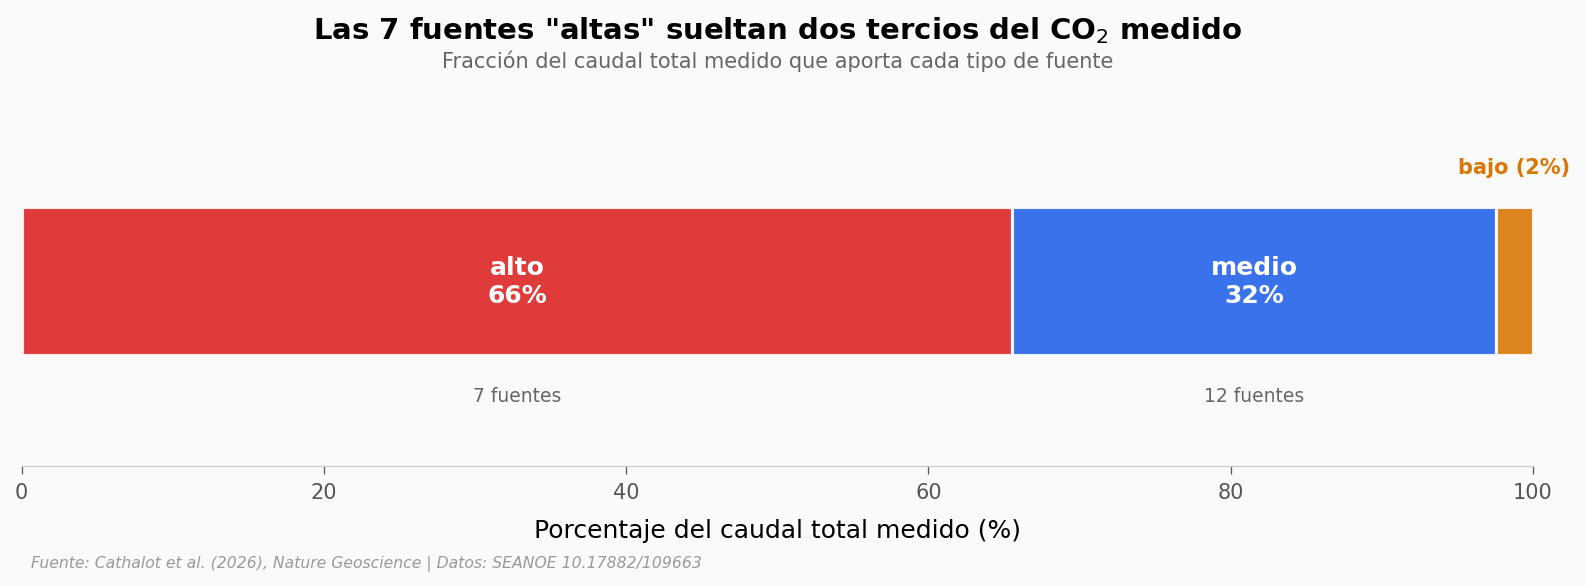

In [3]:
# Cuanto del caudal total medido aporta cada tipo de fuente
contrib = seeps.groupby('typology').agg(n=('flow_rate_mls', 'size'),
                                         total=('flow_rate_mls', 'sum'))
contrib['pct'] = contrib['total'] / contrib['total'].sum() * 100
contrib = contrib.reindex(['High', 'Medium', 'Low'])  # alto -> bajo

fig, ax = plt.subplots(figsize=(13, 3.2))
etiquetas = {'High': 'alto', 'Medium': 'medio', 'Low': 'bajo'}
colores = {'High': COLOR_ALTO, 'Medium': COLOR_MEDIO, 'Low': COLOR_BAJO}

izquierda = 0
for tipo in ['High', 'Medium', 'Low']:
    pct = contrib.loc[tipo, 'pct']
    ax.barh(0, pct, left=izquierda, color=colores[tipo], alpha=0.9, edgecolor='white', linewidth=1.5)
    # Etiqueta dentro del segmento si hay espacio, encima si es muy angosto
    if pct > 8:
        ax.text(izquierda + pct / 2, 0, f'{etiquetas[tipo]}\n{pct:.0f}%',
                ha='center', va='center', fontsize=12, fontweight='bold', color='white')
    else:
        ax.text(izquierda + pct / 2, 0.62, f'{etiquetas[tipo]} ({pct:.0f}%)',
                ha='center', va='center', fontsize=10, fontweight='bold', color=colores[tipo])
    izquierda += pct

# Conteo de fuentes bajo cada segmento
ax.text(contrib.loc['High', 'pct'] / 2, -0.62, f"{int(contrib.loc['High','n'])} fuentes",
        ha='center', va='center', fontsize=9, color='#666666')
ax.text(contrib.loc['High', 'pct'] + contrib.loc['Medium', 'pct'] / 2, -0.62,
        f"{int(contrib.loc['Medium','n'])} fuentes", ha='center', va='center', fontsize=9, color='#666666')

ax.set_title('Las 7 fuentes "altas" sueltan dos tercios del CO$_2$ medido',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.08, 'Fracción del caudal total medido que aporta cada tipo de fuente',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlim(0, 100)
ax.set_ylim(-1, 1)
ax.set_yticks([])
ax.set_xlabel('Porcentaje del caudal total medido (%)')
ax.spines['left'].set_visible(False)
ax.grid(False)

fig.text(0.13, -0.10, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/contribucion.png', dpi=200, bbox_inches='tight')
plt.show()

## El campo entero: una extrapolación

Las 7 fuentes "altas" son un tercio de las medidas, pero sueltan dos tercios del caudal. Y el ROV solo alcanzó a medir 22 — el campo tiene muchas más. Para estimar cuánto suelta el campo completo, el equipo no contó una por una: corrió una simulación Monte Carlo que reparte el caudal medido sobre toda el área. Esa simulación tiene dos perillas: cómo se **distribuyen** las fuentes en el espacio (Random, Dirichlet o Normal) y cómo se modela su **densidad** (Beta o Normal). ¿Cuál de las dos mueve el resultado?

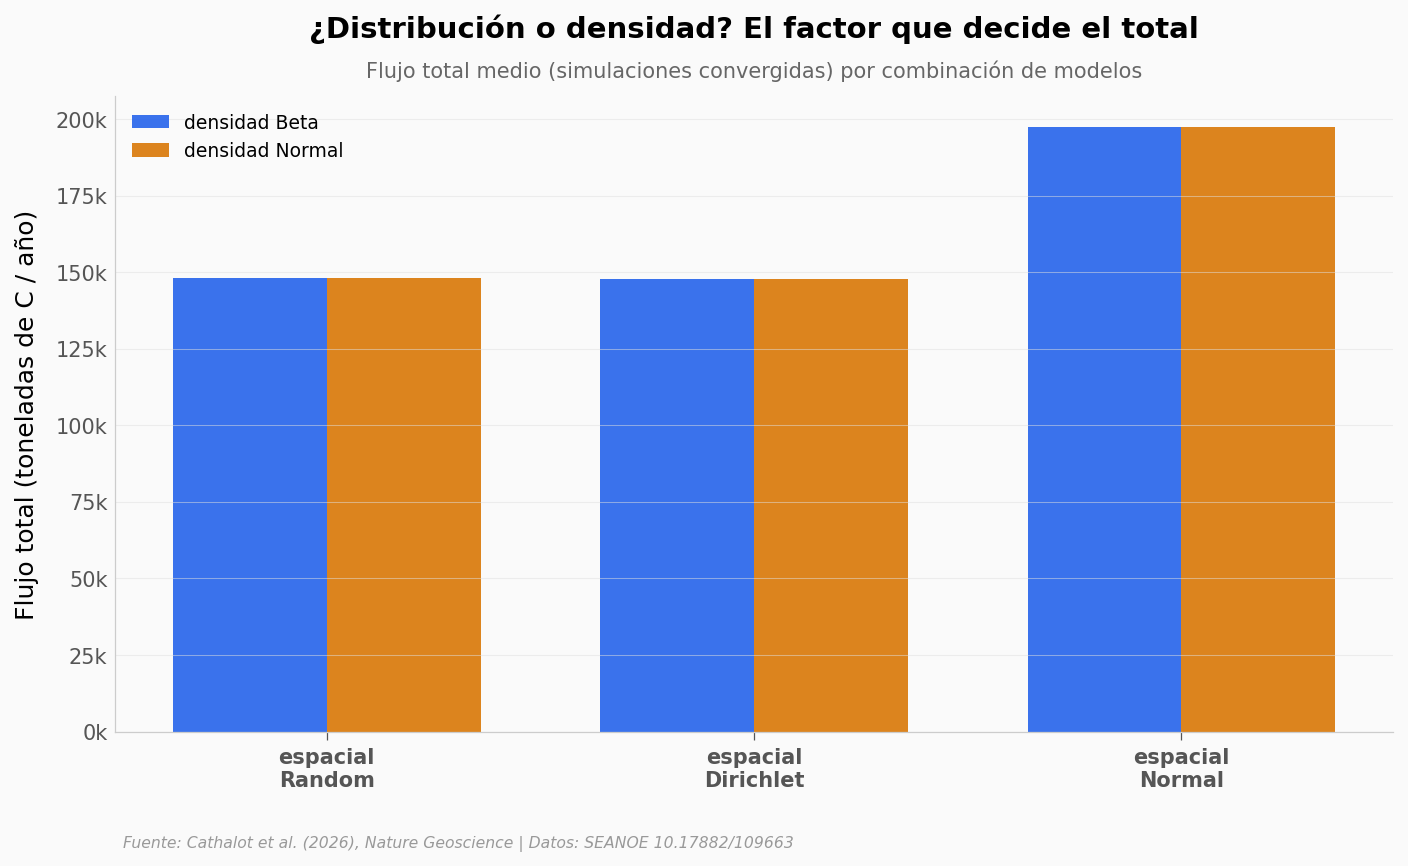

In [4]:
# Comparacion: que factor decide el total, distribucion espacial o densidad
conv = flux[flux['n_simulations'] >= 10000]
tabla = conv.groupby(['dist_model', 'dens_model'])['flux_tC_per_y'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5.5))
spatials = ['Random', 'Dirichlet', 'Normal']
x = np.arange(len(spatials))
ancho = 0.36
dens_colores = {'Beta': '#2563EB', 'Normal': '#D97706'}

for i, dens in enumerate(['Beta', 'Normal']):
    valores = [tabla[(tabla['dist_model'] == sp) & (tabla['dens_model'] == dens)]['flux_tC_per_y'].iloc[0]
               for sp in spatials]
    ax.bar(x + (i - 0.5) * ancho, valores, ancho, color=dens_colores[dens],
           alpha=0.9, label=f'densidad {dens}')

ax.set_title('¿Distribución o densidad? El factor que decide el total', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Flujo total medio (simulaciones convergidas) por combinación de modelos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(x)
ax.set_xticklabels([f'espacial\n{sp}' for sp in spatials], fontsize=10, fontweight='bold')
ax.set_ylabel('Flujo total (toneladas de C / año)')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend(fontsize=9, loc='upper left')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/modelos.png', dpi=200, bbox_inches='tight')
plt.show()

## Entonces, ¿cuál es el número?

Cambiar el modelo de densidad casi no mueve el resultado. Cambiar la distribución espacial sí: Random y Dirichlet caen cerca de 148 mil toneladas de carbono al año; el modelo Normal sube a unas 198 mil. Misma medición, dos números separados por un 34%. Veamos cómo se ve toda la incertidumbre junta.

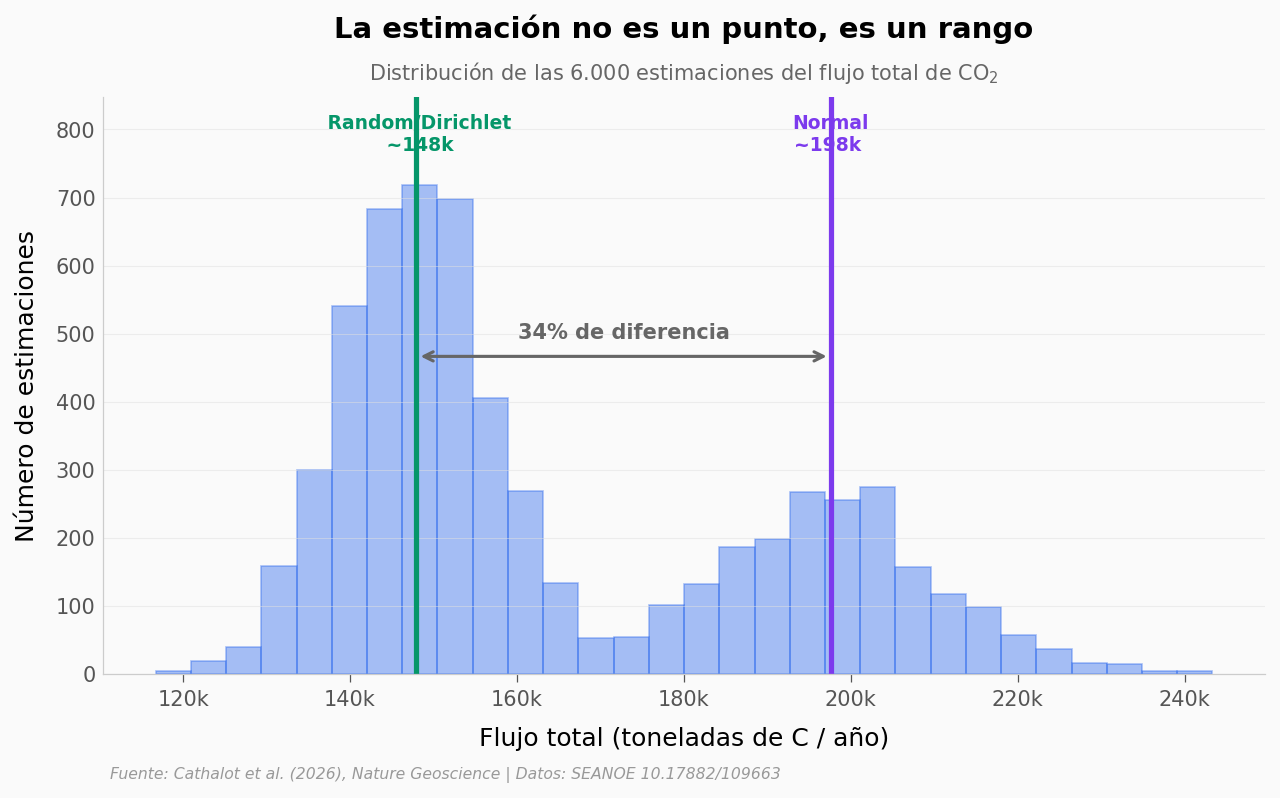

Mediana global: 153.622 tC/ano  ->  563.282 tCO2/ano


In [5]:
# Histograma de todas las estimaciones — la incertidumbre del numero final
fig, ax = plt.subplots(figsize=(10, 5))

datos = flux['flux_tC_per_y'].values
n, bins, patches = ax.hist(datos, bins=30, color='#2563EB', alpha=0.4,
                           edgecolor='#2563EB', linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

mediana = np.median(datos)
c_otros = conv[conv['dist_model'].isin(['Random', 'Dirichlet'])]['flux_tC_per_y'].mean()
c_normal = conv[conv['dist_model'] == 'Normal']['flux_tC_per_y'].mean()

ax.axvline(c_otros, color=COLOR_OTROS, linewidth=2.5)
ax.axvline(c_normal, color=COLOR_NORMAL, linewidth=2.5)
ax.text(c_otros, y_max * 0.97, f' Random/Dirichlet\n ~{c_otros/1000:.0f}k',
        fontsize=9, color=COLOR_OTROS, fontweight='bold', ha='center', va='top')
ax.text(c_normal, y_max * 0.97, f'Normal\n~{c_normal/1000:.0f}k ',
        fontsize=9, color=COLOR_NORMAL, fontweight='bold', ha='center', va='top')

# Flecha del spread entre los dos grupos
ax.annotate('', xy=(c_normal, y_max * 0.55), xytext=(c_otros, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((c_otros + c_normal) / 2, y_max * 0.58, '34% de diferencia',
        fontsize=10, color='#666666', ha='center', fontweight='bold')

ax.set_title('La estimación no es un punto, es un rango', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de las 6.000 estimaciones del flujo total de CO$_2$',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Flujo total (toneladas de C / año)')
ax.set_ylabel('Número de estimaciones')
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/incertidumbre.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Mediana global: {mediana:,.0f} tC/ano  ->  {mediana*44/12:,.0f} tCO2/ano'.replace(',', '.'))

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El campo tiene fuentes de CO₂ de caudal muy desigual | ✅ | 22 fuentes medidas; mediana 19,24 ml/s, máximo 132,5 ml/s; distribución sesgada a la derecha (Shapiro *p* = 0,0003) |
| Las fuentes "altas" superan a las "bajas" por ~11× | ✅ | Media alta 65,22 ml/s (n=7) vs baja 5,67 ml/s (n=3) → 11,5×. Grupos pequeños: es un contraste descriptivo, no un test |
| Las 7 fuentes "altas" aportan ~2/3 del caudal medido | ✅ | 65,5% del caudal total medido (696,5 ml/s) viene de las 7 fuentes "altas", que son el 32% de las medidas. Suma de caudales (métrica aditiva) |
| El flujo total ronda ~154 mil tC/año | ⚠️ | Es una **extrapolación**, no una medición. Mediana de las 6.000 simulaciones = 153.622 tC/año (≈ 563 mil tCO₂/año) |
| El total depende del modelo espacial elegido | ✅ | Random/Dirichlet ≈ 148 mil tC/año vs Normal ≈ 198 mil → 34% de diferencia. El modelo de densidad (Beta/Normal) casi no cambia el resultado |

> **Limitaciones:** El caudal directo se midió en solo 22 fuentes de 5 sitios (18 de ellas en un único sitio, B0). El flujo total del campo es una extrapolación Monte Carlo, sensible a cómo se asume la distribución espacial de las fuentes — por eso lo reportamos como rango (148–198 mil tC/año), no como dato único. Es un estudio observacional: describe lo que el ROV vio, no relaciones de causa-efecto.

## Ahora tú

Los datos están cargados en `seeps` (las 22 mediciones) y `flux` (las 6.000 estimaciones). Tres preguntas para explorar:

1. **¿Cambia la historia si miras el caudal por sitio en vez de por tipo?** Casi todas las fuentes están en el sitio B0. Prueba `seeps.groupby('site')['flow_rate_mls'].describe()`.
2. **¿Cuánto sube el total si crees en el modelo Normal?** Compara la mediana de `flux[flux['dist_model']=='Normal']` contra la de los otros dos modelos espaciales.
3. **¿La profundidad tiene algo que ver con el caudal?** Calcula la correlación de Spearman entre `depth_m` y `flow_rate_mls`. (Pista: con n=22 y datos no normales, Spearman es más honesto que Pearson.)

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿la profundidad se relaciona con el caudal de la fuente?
rho, p = stats.spearmanr(seeps['depth_m'], seeps['flow_rate_mls'])
print(f'Correlación de Spearman profundidad vs caudal: rho = {rho:.3f}, p = {p:.3f}  (n = {len(seeps)})')
if p > 0.05:
    print('No hay evidencia de relación: el caudal no sube ni baja sistemáticamente con la profundidad.')
else:
    print('Hay una relación estadísticamente detectable — explórala con un scatter.')

# Cambia 'depth_m' por otra columna, o prueba seeps.groupby('site') para la pregunta 1.

Correlación de Spearman profundidad vs caudal: rho = 0.532, p = 0.011  (n = 22)
Hay una relación estadísticamente detectable — explórala con un scatter.


---

## Fuentes

**Paper**: [Large CO2 seeps and hydrate field on the seafloor offshore Mayotte Island](https://doi.org/10.1038/s41561-026-02004-2)  
*Nature Geoscience, 2026-06-12 · paywall*

**Datos**: [Extrapolated CO2 fluxes over the entire Horseshoe area using different distribution models (Cathalot et al. 2026) + direct ROV flow-rate measurements at site B0](https://doi.org/10.17882/109663)

**Referencias citadas**: [GEOFLAMME expedition: ROV Victor 6000 dive videos in the HORSESHOE area](https://doi.org/10.17882/113745)

*13 afirmaciones del notebook verificadas contra estas fuentes*